# Лабораторная работа №3 (2й семестр)


----

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression

df = pd.read_csv('lab_03/data.csv', sep=';')
df.rename(columns={'date1': 'month', 'date2': 'year', 'x2': 'avg_daily_rate'}, inplace=True)
df.drop(columns=['x1', 'x3', 'x4'], inplace=True)
df['avg_daily_rate'] = df['avg_daily_rate'].apply(lambda x: '.'.join(x.split(',')))
df = df[df['avg_daily_rate'] != ' ']
df['avg_daily_rate'] = df['avg_daily_rate'].astype(float)
df['year'] = df['year'].astype(int)

def month2n(month: str):
    monthes = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
    ]

    return monthes.index(month)


df['month_n'] = df['month'].apply(month2n)
df['timestamp'] = (df['year'] - 1994) * 12 + df['month_n']
df.head()

,month,year,avg_daily_rate,month_n,timestamp
0,January,1994,104.04,0,0
1,February,1994,102.74,1,1
2,March,1994,105.23,2,2
3,April,1994,113.63,3,3
4,May,1994,120.77,4,4


### Тренд при сезонной декомпозиции - скользящее среднее

Окно надо брать кратное периоду сезонности. Если данные по месяцам - k=12

In [31]:
result = seasonal_decompose(df['avg_daily_rate'], model='multiplicative', period=12)

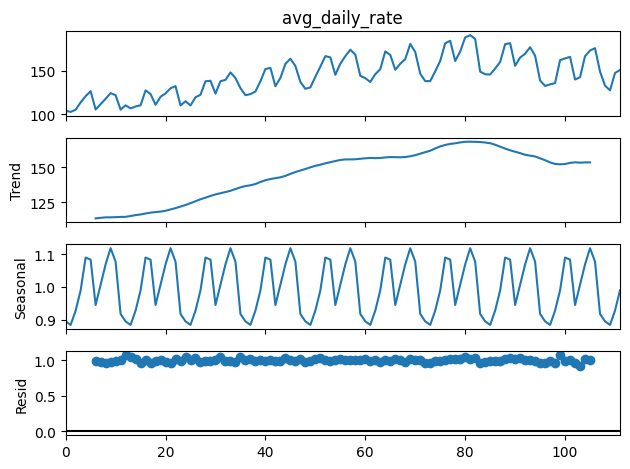

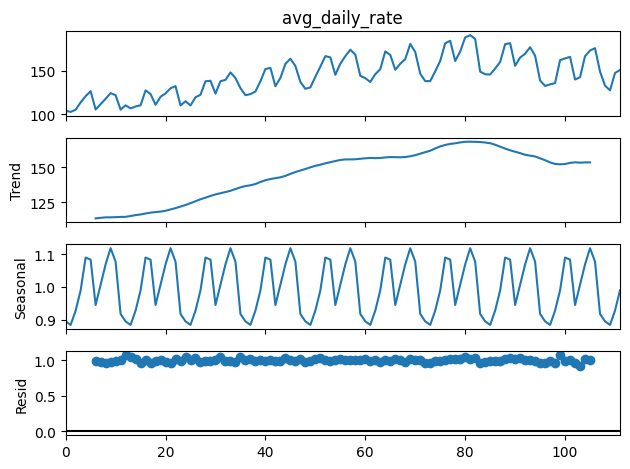

In [32]:
result.plot()

<Axes: >

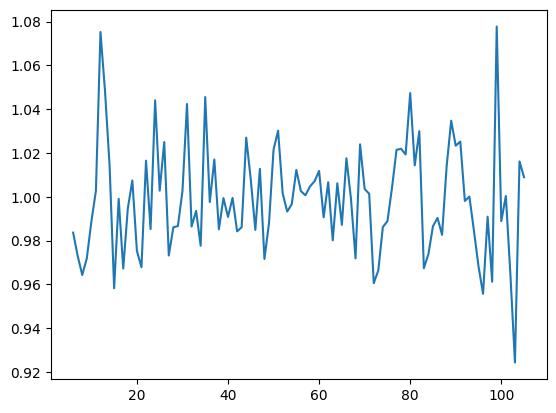

In [33]:
result.resid.plot()

### Погрешность в пределах 8%

In [39]:
X_train = pd.DataFrame(data={
        'ts1': df.timestamp.tail(106).head(100),
        'ts2': df.timestamp.tail(106).head(100) **2,
        'ts3': df.timestamp.tail(106).head(100) ** 3}) # Выбросим месяца когда нет данных о тренде
y_train = result.trend.dropna()

In [40]:
model1 = LinearRegression()
model2 = LinearRegression()
model3 = LinearRegression()

model1.fit(X_train.drop(columns=['ts2', 'ts3']), y_train)
model2.fit(X_train.drop(columns=['ts3']), y_train)
model3.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


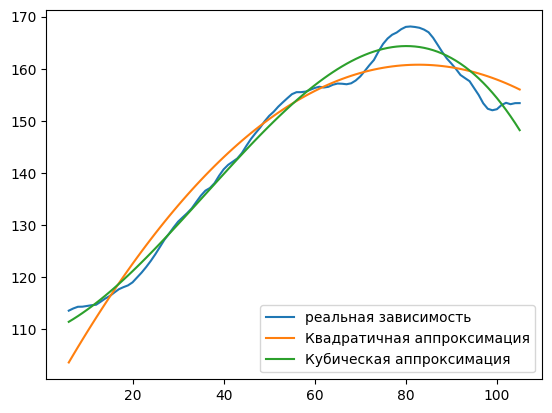

In [49]:
y_tr_for1 = model1.predict(X_train.drop(columns=['ts2', 'ts3']))
y_tr_for2 = model2.predict(X_train.drop(columns=['ts3']))
y_tr_for3 = model3.predict(X_train)


plt.plot(X_train['ts1'], y_train, label='реальная зависимость')
# plt.plot(X_train['ts1'], y_tr_for1, label='Линейная аппроксимация')
plt.plot(X_train['ts1'], y_tr_for2, label='Квадратичная аппроксимация')
plt.plot(X_train['ts1'], y_tr_for3, label='Кубическая аппроксимация')
plt.legend()

### Кадратичная и кубическая аппроксимации справляются неплохо. Возьмём более простую квадратичную

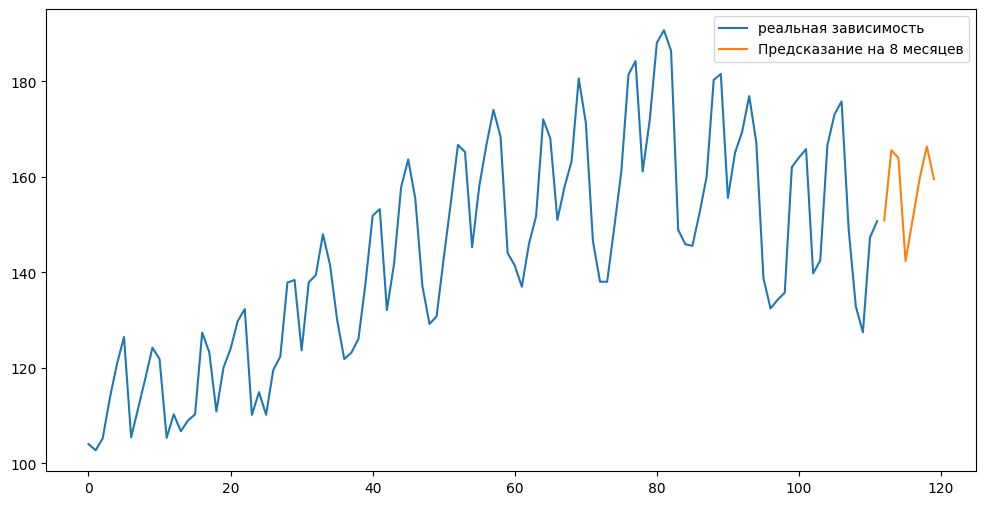

In [87]:
# -- Предсказание на следующие 8 месяцев--
X_forecast = pd.DataFrame(data={
        'ts1': np.arange(112, 120),
        'ts2': np.arange(112, 120) ** 2,
        'ts3': np.arange(112, 120) ** 3})

y_for = model2.predict(X_forecast.drop(columns=['ts3']))

# -- Посмотрим на предсказание --
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['avg_daily_rate'], label='реальная зависимость')
plt.plot(X_forecast['ts1'], y_for * result.seasonal[3:11], label='Предсказание на 8 месяцев') # Здесь домножаем на сезонность, с учётом её текущего положения
plt.legend()

### Кажется предсказание вышло неплохим